In [32]:
print("hello world")

hello world


소속_clean = 소속이 NaN이면 "", 아니면 문자열 strip

팔로워대비_시청자 = 평균_시청자_최댓값 / 최고_팔로워

채팅_뷰어십_비율 = 6분_최고채팅 / 뷰어십

시간당_뷰어십 = 뷰어십 / 총_방송시간

score_view = minmax(뷰어십)
score_chat = minmax(6분_최고채팅)
score_avg = minmax(평균_시청자_최댓값)
score_fandom = minmax(팬덤지수)
score_eff = minmax(시간당_뷰어십)
score_ratio = minmax(팔로워대비_시청자)

프로토스타_score =
0.20 * score_view
+ 0.15 * score_chat
+ 0.25 * score_avg
+ 0.15 * score_fandom
+ 0.15 * score_eff
+ 0.10 * score_ratio

후보군 =
상위 10% 이상 → S급 후보군
상위 30% 이상 → A급 후보군
나머지 → 기타 후보군

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# 경로 설정
# ============================================================

BASE_DIR = Path.cwd()
INPUT_PATH = Path("../../integreted/data/final_softcone_for_team.csv")

df = pd.read_csv(INPUT_PATH, encoding="utf-8-sig")

print(df.shape)
display(df.head())
print(df.columns.tolist())

(11157, 18)


,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,NaN
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,스텔라이브
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,에스더
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,스텔라이브
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,이세계아이돌


['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅', '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수', '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자', '소속']


[숨은보석] : 외형 규모(팔로워)는 아직 작지만, 실제 방송 반응(시청자·채팅·뷰어십)이 높은 성장형 스트리머

**규모 필터 (Low Size)**
최고 팔로워 ↓
유튜브 구독자 ↓
=> 이미 큰 스트리머는 제외

**반응 지표 (High Engagement)**
평균 시청자 최댓값 ↑
최고 시청자 ↑
6분 최고 채팅 ↑
뷰어십 ↑
=> 작은데 반응이 강한 사람

**효율 지표 (핵심)**
팔로워 대비 시청자 비율 ↑
시간당 뷰어십 ↑
팬덤지수 ↑
=> 유입 대비 충성도 높은 구조

**이상치 제거 후 재분석**

In [34]:
import numpy as np

filtered_df = df.copy()

# - 개인세/중소형 후보를 보기 위해 너무 큰 스트리머 제외
# - 팔로워 상위권은 제외하고, 반응 지표가 좋은 후보를 찾음
# 0. 0으로 나누기 방지
filtered_df = filtered_df[
    (filtered_df["최고_팔로워"] > 0) &
    (filtered_df["뷰어십"] > 0) &
    (filtered_df["총_방송시간"] > 0)
].copy()

# 1. 물리적 오류 제거
filtered_df = filtered_df[
    filtered_df["평균_시청자_최댓값"] <= filtered_df["최고_시청자"]
].copy()

# 2. 파생 비율 생성
filtered_df["팔로워대비_시청자"] = (
    filtered_df["평균_시청자_최댓값"] / filtered_df["최고_팔로워"]
)

filtered_df["채팅_뷰어십_비율"] = (
    filtered_df["6분_최고채팅"] / filtered_df["뷰어십"]
)

# 3. 구조적 이상치 1차 제거
filtered_df = filtered_df[
    (filtered_df["팔로워대비_시청자"] <= 0.7) &
    (filtered_df["채팅_뷰어십_비율"] <= 0.1) &
    (filtered_df["총_방송시간"] >= 10)
].copy()

# 4. IQR 기반 극단치 제거 함수
def remove_iqr_outlier(data, col, k=1.5):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + k * iqr

    print(f"{col} IQR 상한:", round(upper, 2))

    return data[data[col] <= upper].copy()

# 5. 그래프에서 문제였던 x/y축 극단치만 제거
# k를 1.5보다 크게 하면 덜 제거, 작게 하면 더 타이트
filtered_df = remove_iqr_outlier(filtered_df, "최고_팔로워", k=1.5)
filtered_df = remove_iqr_outlier(filtered_df, "평균_시청자_최댓값", k=1.5)

# 6. 기존 상위 1% 컷은 채팅/뷰어십에만 적용
# 평균 시청자와 팔로워는 IQR로 처리했기 때문에 중복 제거 방지
for col in ["6분_최고채팅", "뷰어십"]:
    upper = filtered_df[col].quantile(0.99)
    print(f"{col} 상위 1% 기준:", round(upper, 2))
    filtered_df = filtered_df[filtered_df[col] <= upper].copy()

print("원본:", len(df))
print("정제 후:", len(filtered_df))
print("제거 수:", len(df) - len(filtered_df))

최고_팔로워 IQR 상한: 2865.0
평균_시청자_최댓값 IQR 상한: 79.38
6분_최고채팅 상위 1% 기준: 1049.16
뷰어십 상위 1% 기준: 70048.64
원본: 11157
정제 후: 6402
제거 수: 4755


In [35]:
# ============================================================
# 소속 기준 분리
# ============================================================

filtered_df["소속_clean"] = filtered_df["소속"].apply(
    lambda x: "" if pd.isna(x) else str(x).strip()
)

df_true = filtered_df[
    filtered_df["소속_clean"] != ""
].copy()

df_false = filtered_df[
    filtered_df["소속_clean"] == ""
].copy()

print("=" * 30)
print("소속 기준 분리")
print("=" * 30)

print("소속 있음(TRUE):", len(df_true))
print("소속 없음(FALSE + NaN):", len(df_false))
print("전체:", len(filtered_df))

소속 기준 분리
소속 있음(TRUE): 163
소속 없음(FALSE + NaN): 6239
전체: 6402


In [36]:
filtered_df["시간당_뷰어십"] = filtered_df["뷰어십"] / filtered_df["총_방송시간"].replace(0, np.nan)
filtered_df["팔로워대비_시청자"] = filtered_df["평균_시청자_최댓값"] / filtered_df["최고_팔로워"].replace(0, np.nan)

In [ ]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

filtered_df["score_view"] = minmax(filtered_df["뷰어십"])
filtered_df["score_chat"] = minmax(filtered_df["6분_최고채팅"])
filtered_df["score_avg"] = minmax(filtered_df["평균_시청자_최댓값"])
filtered_df["score_fandom"] = minmax(filtered_df["팬덤지수"])
filtered_df["score_eff"] = minmax(filtered_df["시간당_뷰어십"])
filtered_df["score_ratio"] = minmax(filtered_df["팔로워대비_시청자"])

filtered_df["프로토스타_score"] = (
    0.20 * filtered_df["score_view"] +
    0.15 * filtered_df["score_chat"] +
    0.25 * filtered_df["score_avg"] +
    0.15 * filtered_df["score_fandom"] +
    0.15 * filtered_df["score_eff"] +
    0.10 * filtered_df["score_ratio"]
) * 100

In [38]:
s_cut = filtered_df["프로토스타_score"].quantile(0.90)
a_cut = filtered_df["프로토스타_score"].quantile(0.70)

def segment(score):
    if score >= s_cut:
        return "S급 후보군"
    elif score >= a_cut:
        return "A급 후보군"
    else:
        return "기타 후보군"

filtered_df["후보군"] = filtered_df["프로토스타_score"].apply(segment)

In [39]:
# ============================================================
# 후보군 생성 이후 소속 기준 재분리
# ============================================================

filtered_df["소속_clean"] = filtered_df["소속"].apply(
    lambda x: "" if pd.isna(x) else str(x).strip()
)

df_true = filtered_df[
    filtered_df["소속_clean"] != ""
].copy()

df_false = filtered_df[
    filtered_df["소속_clean"] == ""
].copy()

print("소속 있음:", len(df_true))
print("소속 없음:", len(df_false))
print("df_true 후보군 컬럼 있음?", "후보군" in df_true.columns)
print("df_false 후보군 컬럼 있음?", "후보군" in df_false.columns)

소속 있음: 163
소속 없음: 6239
df_true 후보군 컬럼 있음? True
df_false 후보군 컬럼 있음? True


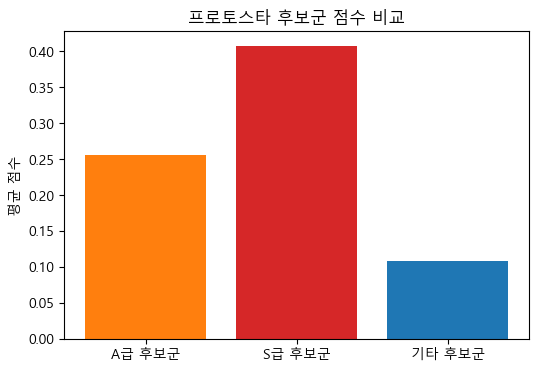

In [40]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

colors = {
    "S급 후보군": "#d62728",
    "A급 후보군": "#ff7f0e",
    "기타 후보군": "#1f77b4",
}

summary = filtered_df.groupby("후보군")["프로토스타_score"].mean()

plt.figure(figsize=(6,4))
plt.bar(summary.index, summary.values, color=[colors[x] for x in summary.index])

plt.title("프로토스타 후보군 점수 비교")
plt.ylabel("평균 점수")
plt.show()

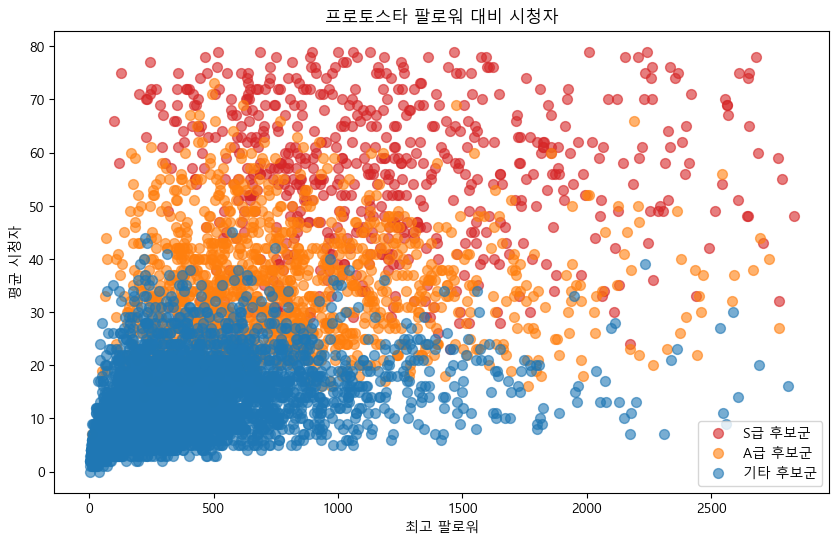

In [41]:
plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
    temp = filtered_df[filtered_df["후보군"] == seg]
    
    plt.scatter(
        temp["최고_팔로워"],
        temp["평균_시청자_최댓값"],
        label=seg,
        color=colors[seg],
        alpha=0.6,
        s=50
    )

plt.title("프로토스타 팔로워 대비 시청자")
plt.xlabel("최고 팔로워")
plt.ylabel("평균 시청자")
plt.legend()
plt.show()

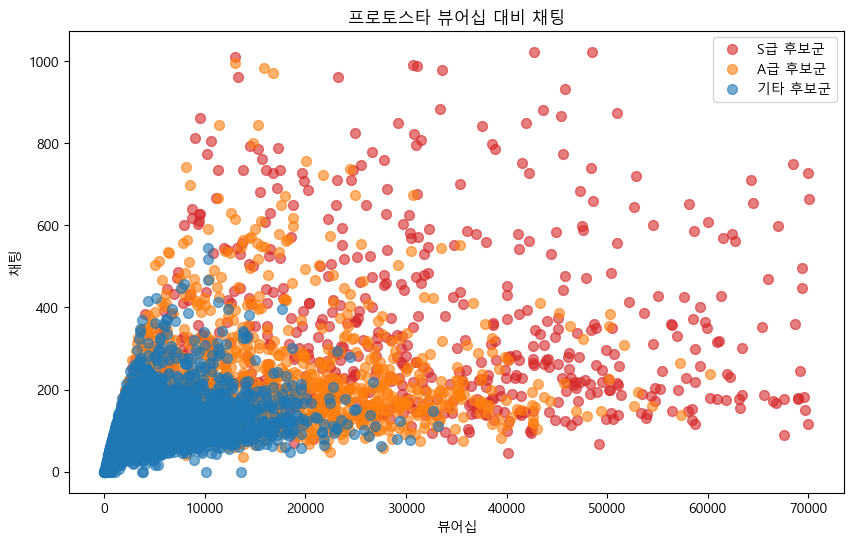

In [42]:
plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
    temp = filtered_df[filtered_df["후보군"] == seg]
    
    plt.scatter(
        temp["뷰어십"],
        temp["6분_최고채팅"],
        label=seg,
        color=colors[seg],
        alpha=0.6,
        s=50
    )

plt.title("프로토스타 뷰어십 대비 채팅")
plt.xlabel("뷰어십")
plt.ylabel("채팅")
plt.legend()
plt.show()

In [43]:
# 개수
count_df = filtered_df["후보군"].value_counts().reset_index()
count_df.columns = ["후보군", "인원수"]

# 비율 (%)
total = len(filtered_df)
count_df["비율(%)"] = (count_df["인원수"] / total * 100).round(1)

# 보기 좋게 정렬
order = ["S급 후보군", "A급 후보군", "기타 후보군"]
count_df["후보군"] = pd.Categorical(count_df["후보군"], categories=order, ordered=True)
count_df = count_df.sort_values("후보군")

display(count_df)

print("전체 인원:", total)

,후보군,인원수,비율(%)
2,S급 후보군,641,10.0
1,A급 후보군,1280,20.0
0,기타 후보군,4481,70.0


전체 인원: 6402


In [44]:
# 공통으로 볼 컬럼
cols = [
    "스트리머명",
    "최고_팔로워",
    "평균_시청자_최댓값",
    "6분_최고채팅",
    "뷰어십",
    "팔로워대비_시청자",
    "프로토스타_score"
]

# S급
print("\n[S급 후보군 TOP 10]")
display(
    filtered_df[filtered_df["후보군"] == "S급 후보군"]
    .sort_values("프로토스타_score", ascending=False)[cols]
    .head(10)
)

# A급
print("\n[A급 후보군 TOP 10]")
display(
    filtered_df[filtered_df["후보군"] == "A급 후보군"]
    .sort_values("프로토스타_score", ascending=False)[cols]
    .head(10)
)

# 기타
print("\n[기타 후보군 TOP 10]")
display(
    filtered_df[filtered_df["후보군"] == "기타 후보군"]
    .sort_values("프로토스타_score", ascending=False)[cols]
    .head(10)
)


[S급 후보군 TOP 10]


,스트리머명,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
892,꽃분홍,1129,79,117,69927,0.069973,0.652379
1393,문이유,1326,69,1023,42698,0.052036,0.609071
1061,건망고,2648,74,372,58547,0.027946,0.603841
902,라망,1817,60,447,69394,0.033021,0.593862
1190,세피람,1333,73,557,50964,0.054764,0.589143
1059,치즈냥,1854,60,587,58613,0.032362,0.588962
997,백사라,851,55,578,62442,0.064630,0.588893
1102,다정현,2366,75,359,56352,0.031699,0.587162
1129,바또랑,1016,70,310,54596,0.068898,0.584872
955,구름스무디,2681,78,470,65973,0.029094,0.579354



[A급 후보군 TOP 10]


,스트리머명,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
2506,카요리,1112,51,175,18851,0.045863,0.331680
3011,보 라 곰,1233,31,565,13848,0.025142,0.331657
3117,아이링,1002,38,615,13010,0.037924,0.331591
4983,차이니아,563,35,503,5085,0.062167,0.331443
5289,경융,581,54,298,4422,0.092943,0.330960
2134,크류키,511,25,738,24455,0.048924,0.330875
1978,은설또,1258,37,368,27211,0.029412,0.330608
2790,럿질그저,432,65,169,15972,0.150463,0.330573
5177,유치에,661,57,103,4674,0.086233,0.330471
1175,예나츄,1160,27,308,51643,0.023276,0.330220



[기타 후보군 TOP 10]


,스트리머명,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
7697,혜팔,241,35,74,1294,0.145228,0.199366
4268,하이렌,553,27,276,7134,0.048825,0.199360
2630,김지이,802,18,134,17543,0.022444,0.199306
4267,솔연,897,25,147,7138,0.027871,0.199277
2525,시후,517,18,301,18631,0.034816,0.199249
3835,능비,800,31,141,8885,0.038750,0.199244
2994,솔피,607,30,143,14004,0.049423,0.199201
3443,린나따,610,28,107,10827,0.045902,0.199178
3789,종이,1571,23,187,9124,0.014640,0.199112
4589,하샛별,592,27,189,6126,0.045608,0.199093


분석 결과, S급 후보군은 동일 규모 대비 높은 시청자 반응과 채팅 참여도를 보이며 플랫폼 내 강한 팬덤 밀도를 가진 집단으로 나타났다. 다만 분포 구조상 소수의 S급 후보가 전체 평균과 반응 지표를 크게 끌어올리는 양상이 확인되었으며, 실제 영입 경쟁과 비용 측면에서도 접근 난이도가 높은 편이다.

반면 A급 후보군은 극단적인 수치는 아니지만 안정적인 시청자 반응과 성장 가능성을 보였으며, 현실적인 영입 가능성과 장기 성장 측면에서 보다 효율적인 타겟으로 판단되었다.

따라서 CIME의 영입 전략은 S급 후보를 브랜드 인지도 및 플랫폼 확장용으로 일부 확보하되, 실제 플랫폼 성장 기반은 A급 중심의 숨은보석형 스트리머를 다수 확보하는 ‘투 트랙 전략(Two-Track Strategy)’이 효과적일 것으로 판단된다.

In [45]:
score_cols = [
    "score_view",
    "score_chat",
    "score_avg",
    "score_fandom",
    "score_eff",
    "score_ratio"
]

# 표준편차 계산
stds = filtered_df[score_cols].std()

# 가중치 비율화
weights = stds / stds.sum()

print("=" * 60)
print("표준편차 계산을 통한 프로토스타_score 가중치 비율화")
print("=" * 60)
print(weights)

표준편차 계산을 통한 프로토스타_score 가중치 비율화
score_view      0.191429
score_chat      0.140580
score_avg       0.249486
score_fandom    0.166592
score_eff       0.144547
score_ratio     0.107367
dtype: float64


In [46]:
colors = {
    "S급 후보군": "#d62728",
    "A급 후보군": "#ff7f0e",
    "기타 후보군": "#1f77b4"
}

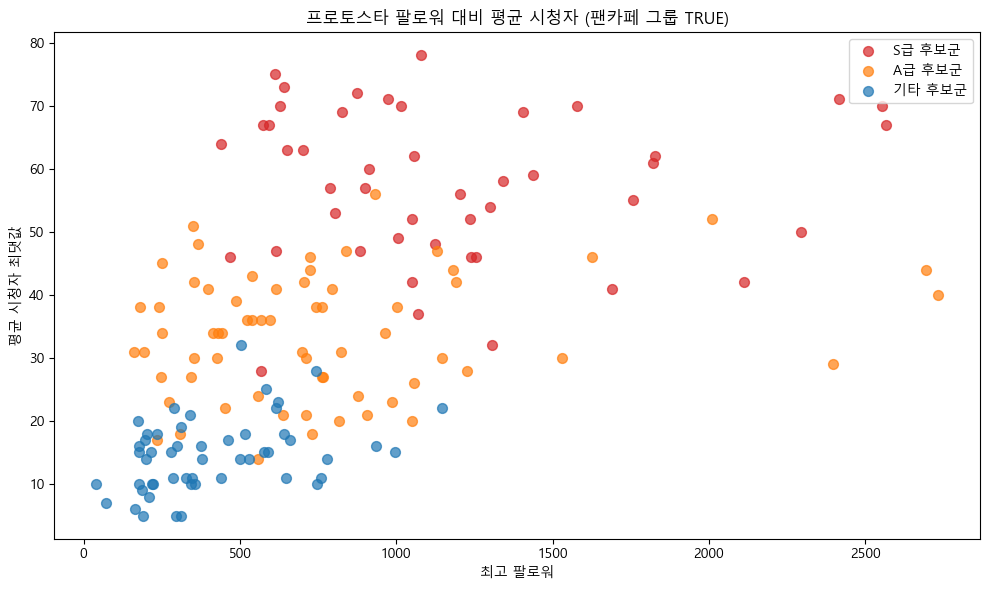

In [47]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:

    temp = df_true[df_true["후보군"] == seg]

    plt.scatter(
        temp["최고_팔로워"],
        temp["평균_시청자_최댓값"],
        label=seg,
        color=colors[seg],
        alpha=0.7,
        s=50
    )

plt.title("프로토스타 팔로워 대비 평균 시청자 (팬카페 그룹 TRUE)")
plt.xlabel("최고 팔로워")
plt.ylabel("평균 시청자 최댓값")

plt.legend()
plt.tight_layout()
plt.show()

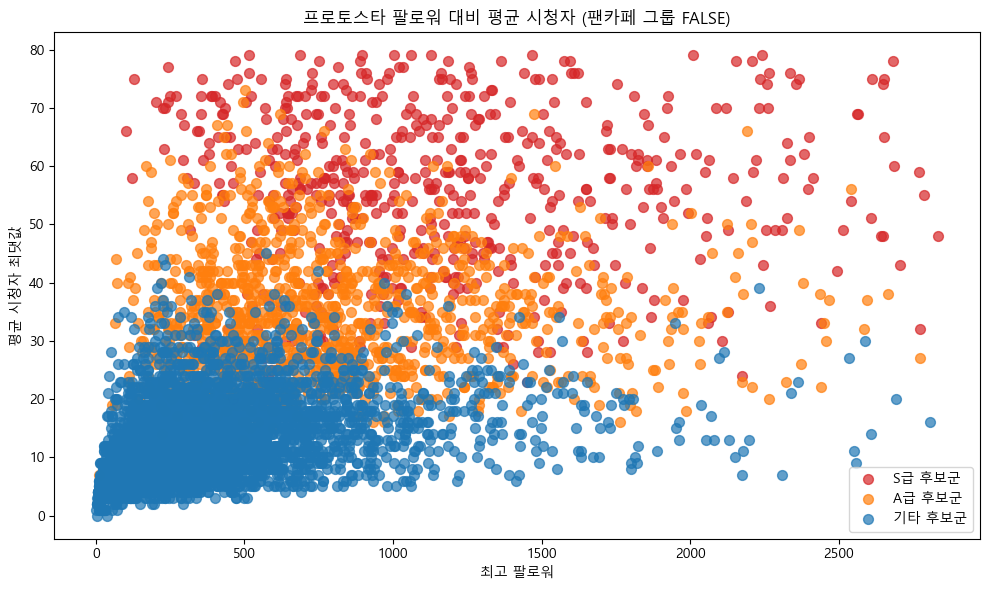

In [48]:
plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:

    temp = df_false[df_false["후보군"] == seg]

    plt.scatter(
        temp["최고_팔로워"],
        temp["평균_시청자_최댓값"],
        label=seg,
        color=colors[seg],
        alpha=0.7,
        s=50
    )

plt.title("프로토스타 팔로워 대비 평균 시청자 (팬카페 그룹 FALSE)")
plt.xlabel("최고 팔로워")
plt.ylabel("평균 시청자 최댓값")

plt.legend()
plt.tight_layout()
plt.show()

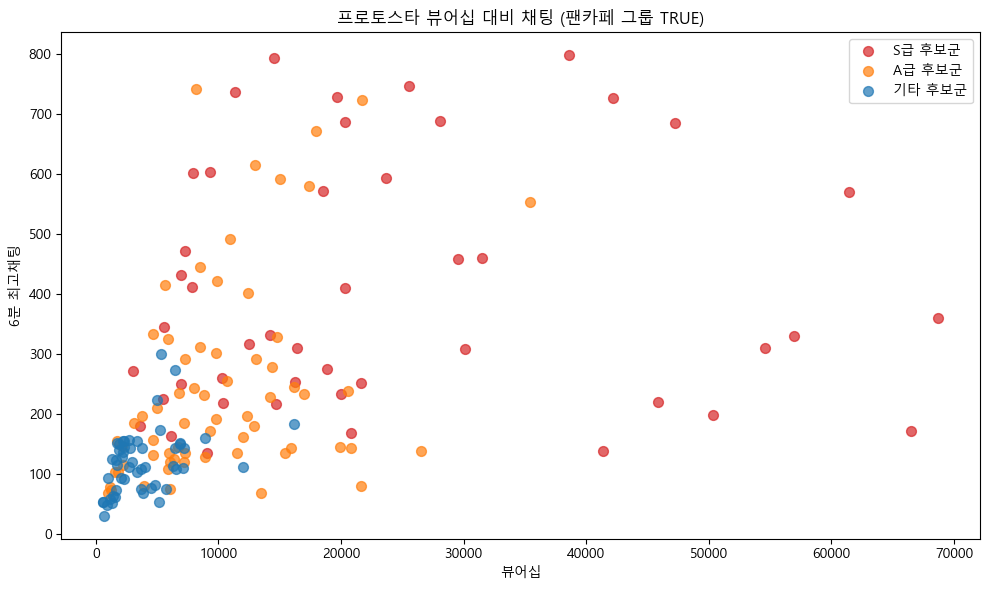

In [49]:
plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:

    temp = df_true[df_true["후보군"] == seg]

    plt.scatter(
        temp["뷰어십"],
        temp["6분_최고채팅"],
        label=seg,
        color=colors[seg],
        alpha=0.7,
        s=50
    )

plt.title("프로토스타 뷰어십 대비 채팅 (팬카페 그룹 TRUE)")
plt.xlabel("뷰어십")
plt.ylabel("6분 최고채팅")

plt.legend()
plt.tight_layout()
plt.show()

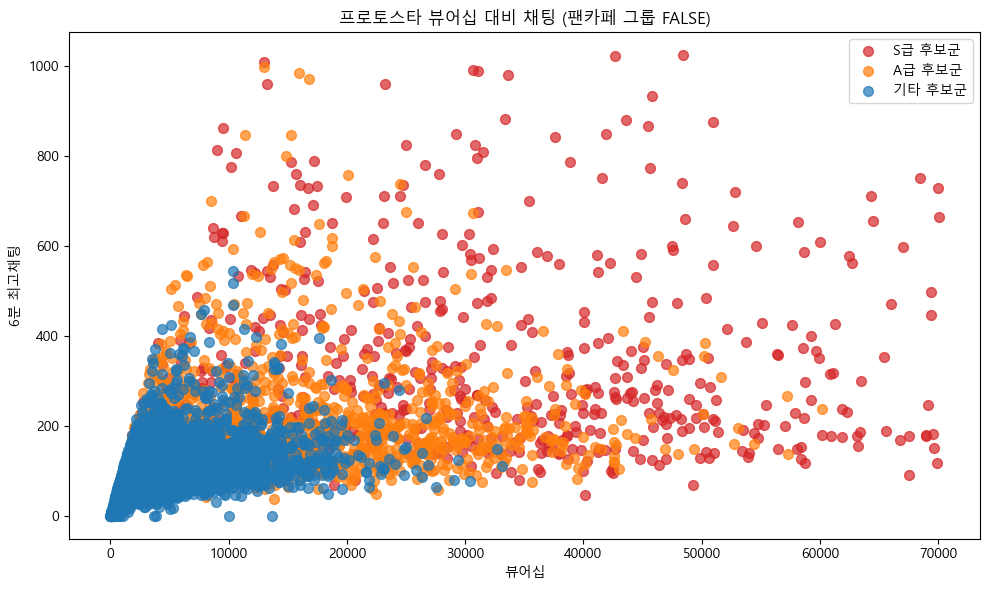

In [50]:
plt.figure(figsize=(10,6))

for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:

    temp = df_false[df_false["후보군"] == seg]

    plt.scatter(
        temp["뷰어십"],
        temp["6분_최고채팅"],
        label=seg,
        color=colors[seg],
        alpha=0.7,
        s=50
    )

plt.title("프로토스타 뷰어십 대비 채팅 (팬카페 그룹 FALSE)")
plt.xlabel("뷰어십")
plt.ylabel("6분 최고채팅")

plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# 공통 컬럼
# ============================================================

cols = [
    "스트리머명",
    "소속",
    "최고_팔로워",
    "평균_시청자_최댓값",
    "6분_최고채팅",
    "뷰어십",
    "팔로워대비_시청자",
    "프로토스타_score"
]

# ============================================================
# 안전 체크
# ============================================================

required_cols = ["소속", "후보군", "프로토스타_score"]

missing = [col for col in required_cols if col not in filtered_df.columns]

if missing:
    raise KeyError(f"필수 컬럼이 없습니다: {missing}")

# ============================================================
# 소속_clean 생성
# 원본 '소속' 컬럼은 절대 덮어쓰지 않음
# ============================================================

filtered_df["소속_clean"] = filtered_df["소속"].apply(
    lambda x: "" if pd.isna(x) else str(x).strip()
)

# ============================================================
# 소속 있음 / 없음 분리
# ============================================================

df_true = filtered_df[
    filtered_df["소속_clean"] != ""
].copy()

df_false = filtered_df[
    filtered_df["소속_clean"] == ""
].copy()

print("소속 있음:", len(df_true))
print("소속 없음:", len(df_false))
print("df_true 후보군 있음?", "후보군" in df_true.columns)
print("df_false 후보군 있음?", "후보군" in df_false.columns)

# ============================================================
# 함수
# ============================================================

def show_top10_by_group(df, group_name):

    print("=" * 60)
    print(f"[소속 그룹 {group_name}]")
    print("=" * 60)

    for seg in ["S급 후보군", "A급 후보군", "기타 후보군"]:
        print(f"\n[{seg} TOP 10]")

        display(
            df[df["후보군"] == seg]
            .sort_values("프로토스타_score", ascending=False)[cols]
            .head(10)
        )

# ============================================================
# 실행
# ============================================================

show_top10_by_group(df_true, "소속 있음")
show_top10_by_group(df_false, "소속 없음")

소속 있음: 163
소속 없음: 6239
df_true 후보군 있음? True
df_false 후보군 있음? True
[소속 그룹 소속 있음]

[S급 후보군 TOP 10]


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
1129,바또랑,이매방랑,1016,70,310,54596,0.068898,0.584872
1413,윰로로,없음,1828,62,727,42185,0.033917,0.572828
916,홍세리,러쉬,2417,71,360,68712,0.029375,0.563746
2078,이안,유네트,1078,78,747,25565,0.072356,0.550548
1203,엘 카오스 라이메데,브이시즈,1341,58,198,50318,0.043251,0.505883
1275,유상츄,러브레이,1237,52,685,47277,0.042037,0.498095
1316,루센,없음,2555,70,219,45862,0.027397,0.496429
1089,코기사와 코코로,지엔즈,2294,50,330,56961,0.021796,0.493215
1016,이라,이리스,2112,42,570,61466,0.019886,0.490581
947,아춘향,브이시즈,1254,46,171,66526,0.036683,0.489505



[A급 후보군 TOP 10]


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
3117,아이링,걸즈원,1002,38,615,13010,0.037924,0.331591
3742,이 치 치,러브포에트,725,44,171,9349,0.060690,0.328988
4001,하찬찬,베가본드,413,34,742,8164,0.082324,0.328658
2327,효굴효굴,주스,932,56,80,21665,0.060086,0.326655
4234,루나 ㅣ나름아이,나름아이,1627,46,291,7251,0.028273,0.325941
2391,도일이,없음,352,42,238,20585,0.119318,0.323212
4033,아샤 누아르,러브포에트,793,41,242,8044,0.051702,0.319725
5172,몬드몬드,그림토피아,399,41,131,4681,0.102757,0.318098
2953,김미키,다락방,2010,52,278,14365,0.025871,0.312545
3633,이새난,유부녀즈,2694,44,191,9821,0.016333,0.310569



[기타 후보군 TOP 10]


...

,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
892,꽃분홍,NaN,1129,79,117,69927,0.069973,0.652379
1393,문이유,NaN,1326,69,1023,42698,0.052036,0.609071
1061,건망고,NaN,2648,74,372,58547,0.027946,0.603841
902,라망,NaN,1817,60,447,69394,0.033021,0.593862
1190,세피람,NaN,1333,73,557,50964,0.054764,0.589143
1059,치즈냥,NaN,1854,60,587,58613,0.032362,0.588962
997,백사라,NaN,851,55,578,62442,0.064630,0.588893
1102,다정현,NaN,2366,75,359,56352,0.031699,0.587162
955,구름스무디,NaN,2681,78,470,65973,0.029094,0.579354
1510,잉요,NaN,1019,77,271,38952,0.075564,0.576408



[A급 후보군 TOP 10]


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
2506,카요리,NaN,1112,51,175,18851,0.045863,0.331680
3011,보 라 곰,NaN,1233,31,565,13848,0.025142,0.331657
4983,차이니아,NaN,563,35,503,5085,0.062167,0.331443
5289,경융,NaN,581,54,298,4422,0.092943,0.330960
2134,크류키,NaN,511,25,738,24455,0.048924,0.330875
1978,은설또,NaN,1258,37,368,27211,0.029412,0.330608
2790,럿질그저,NaN,432,65,169,15972,0.150463,0.330573
5177,유치에,NaN,661,57,103,4674,0.086233,0.330471
1175,예나츄,NaN,1160,27,308,51643,0.023276,0.330220
2886,벨 마,NaN,670,53,196,14964,0.079104,0.330074



[기타 후보군 TOP 10]


,스트리머명,소속,최고_팔로워,평균_시청자_최댓값,6분_최고채팅,뷰어십,팔로워대비_시청자,프로토스타_score
7697,혜팔,NaN,241,35,74,1294,0.145228,0.199366
4268,하이렌,NaN,553,27,276,7134,0.048825,0.199360
2630,김지이,NaN,802,18,134,17543,0.022444,0.199306
4267,솔연,NaN,897,25,147,7138,0.027871,0.199277
2525,시후,NaN,517,18,301,18631,0.034816,0.199249
3835,능비,NaN,800,31,141,8885,0.038750,0.199244
2994,솔피,NaN,607,30,143,14004,0.049423,0.199201
3443,린나따,NaN,610,28,107,10827,0.045902,0.199178
3789,종이,NaN,1571,23,187,9124,0.014640,0.199112
4589,하샛별,NaN,592,27,189,6126,0.045608,0.199093


**[더미 시각화]**

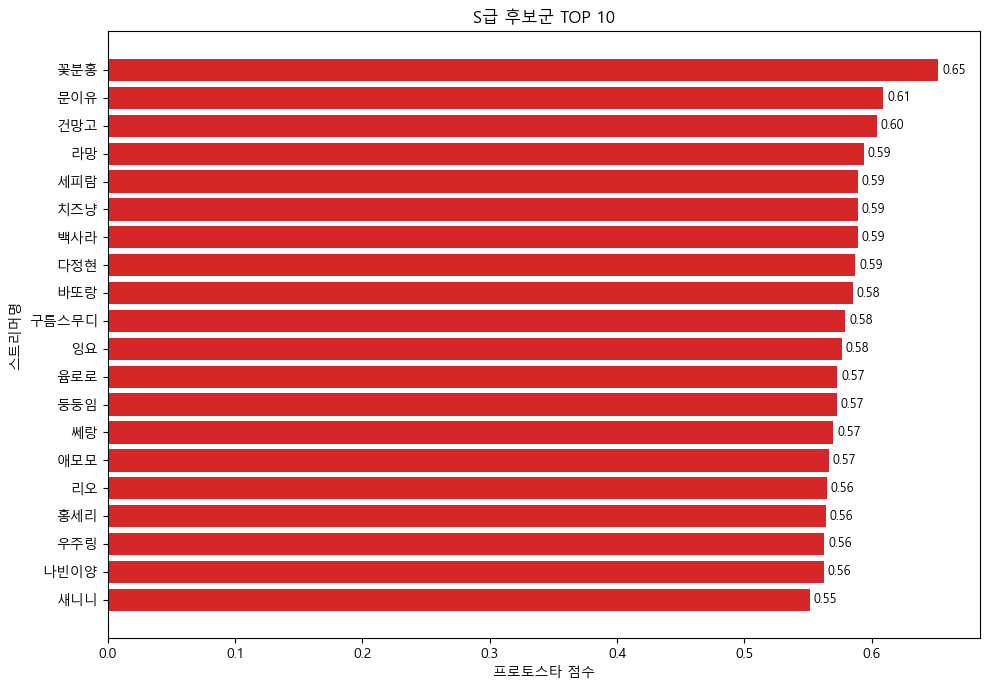

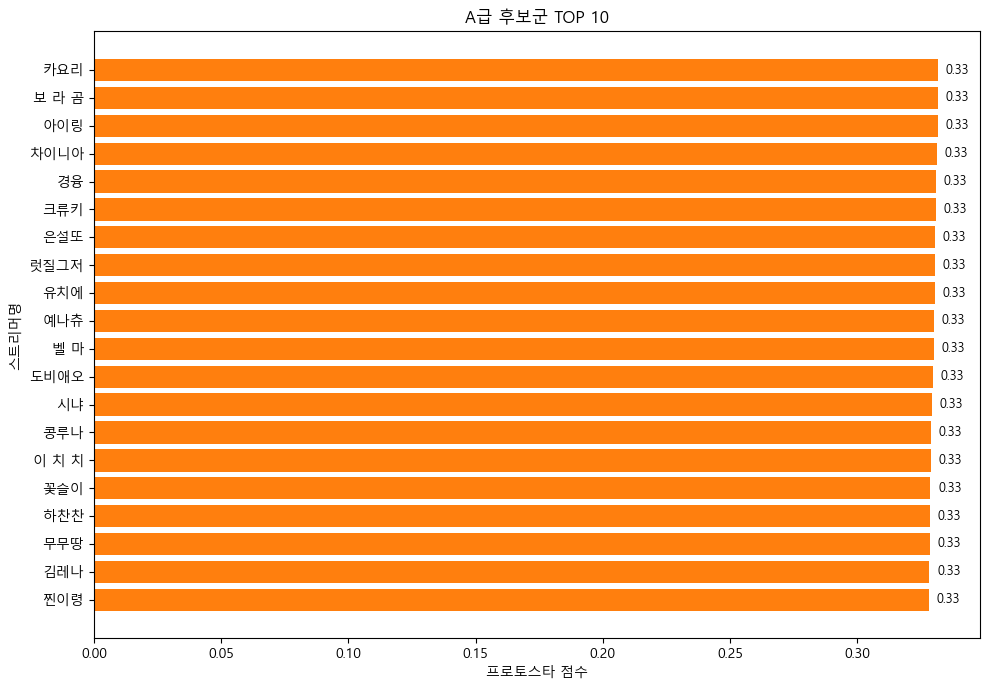

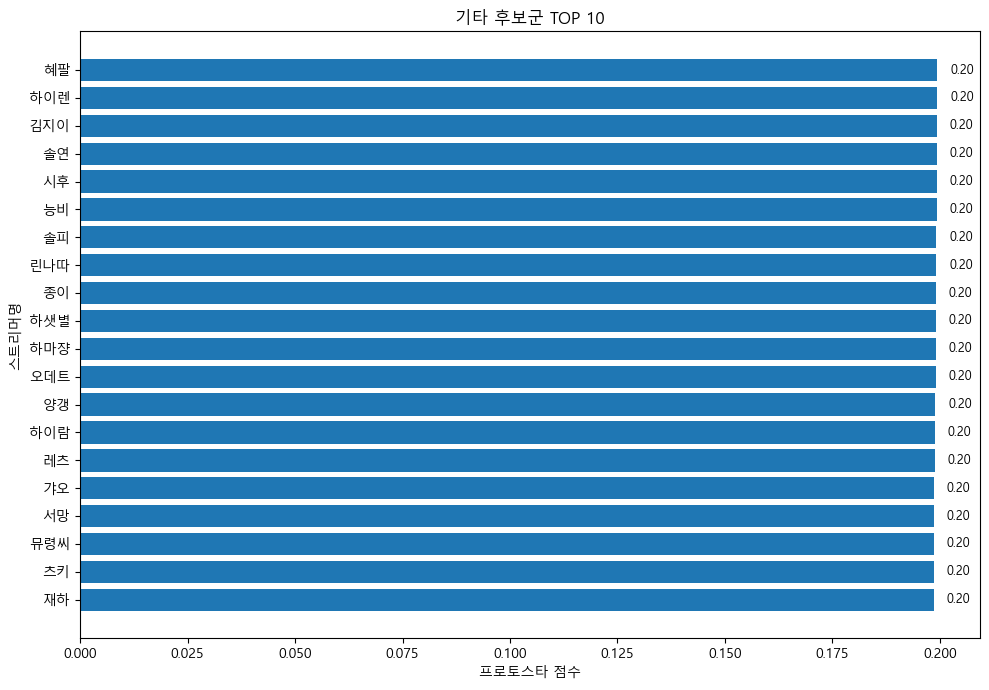

In [52]:
import matplotlib.pyplot as plt

# ============================================================
# 한글 폰트 설정
# ============================================================

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 색상 설정
# ============================================================

colors = {
    "S급 후보군": "#d62728",   # 빨강
    "A급 후보군": "#ff7f0e",   # 주황
    "기타 후보군": "#1f77b4"   # 파랑
}

# ============================================================
# 후보군별 TOP10 추출
# ============================================================

top_s = (
    filtered_df[filtered_df["후보군"] == "S급 후보군"]
    .sort_values("프로토스타_score", ascending=False)
    .head(20)
    .sort_values("프로토스타_score")
)

top_a = (
    filtered_df[filtered_df["후보군"] == "A급 후보군"]
    .sort_values("프로토스타_score", ascending=False)
    .head(20)
    .sort_values("프로토스타_score")
)

top_b = (
    filtered_df[filtered_df["후보군"] == "기타 후보군"]
    .sort_values("프로토스타_score", ascending=False)
    .head(20)
    .sort_values("프로토스타_score")
)

# ============================================================
# 그래프 함수
# ============================================================

def draw_top10(df, title, color):
    
    plt.figure(figsize=(10, 7))

    bars = plt.barh(
        df["스트리머명"],
        df["프로토스타_score"],
        color=color
    )

    # 점수 표시 (둘째자리 반올림)
    for bar in bars:
        width = bar.get_width()

        plt.text(
            width + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            fontsize=9
        )

    plt.title(title)
    plt.xlabel("프로토스타 점수")
    plt.ylabel("스트리머명")

    plt.tight_layout()
    plt.show()

# ============================================================
# 후보군별 시각화
# ============================================================

draw_top10(
    top_s,
    "S급 후보군 TOP 10",
    colors["S급 후보군"]
)

draw_top10(
    top_a,
    "A급 후보군 TOP 10",
    colors["A급 후보군"]
)

draw_top10(
    top_b,
    "기타 후보군 TOP 10",
    colors["기타 후보군"]
)

In [53]:
summary = filtered_df.groupby("후보군")[
    [
        "평균_시청자_최댓값",
        "6분_최고채팅",
        "팬덤지수"
    ]
].mean()

display(summary)

,평균_시청자_최댓값,6분_최고채팅,팬덤지수
후보군,,,
A급 후보군,34.209375,203.157031,-43.559297
S급 후보군,55.900156,329.677067,-40.503276
기타 후보군,12.570632,98.189913,-66.716001


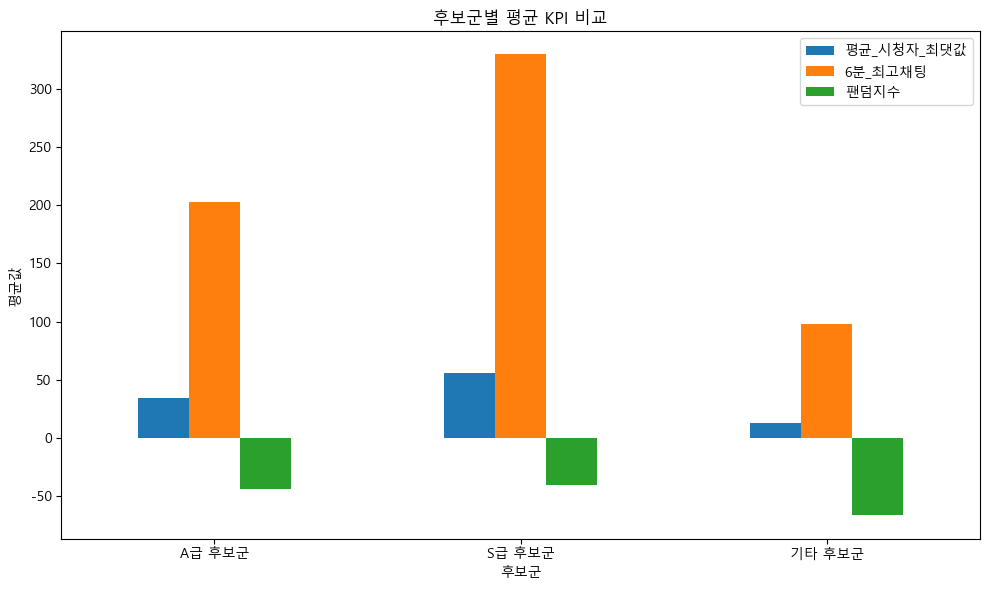

In [54]:
summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("후보군별 평균 KPI 비교")
plt.ylabel("평균값")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
from pathlib import Path

# 경로
path = Path("../../integreted/data/final_softcone_for_team.csv")

df = pd.read_csv(path, encoding="utf-8-sig")

# 찾고 싶은 스트리머 이름
name = "꽃분홍"

result = df[df["스트리머명"] == name]

display(result)

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
892,꽃분홍,CHZZK,354a21d5de27d11b47be0ec8008a89ce,2025.05.01 ~ 2026.03.20,1129,1599,117,40,108,79,69927,372392,-51.2,-35.7,0,30,79,NaN
